In [1]:
###################################################################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
movies=pd.read_csv("movies_updated.csv")
# movies.head()


budget     0
gross     49
score      0
dtype: int64
budget    0
gross     0
score     0
dtype: int64


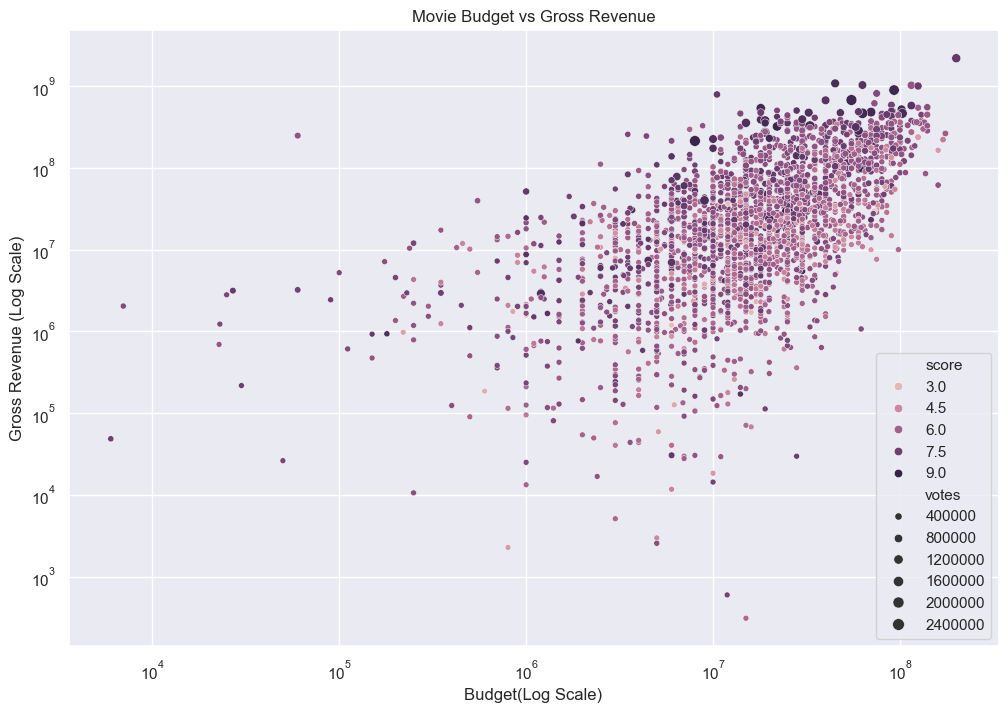

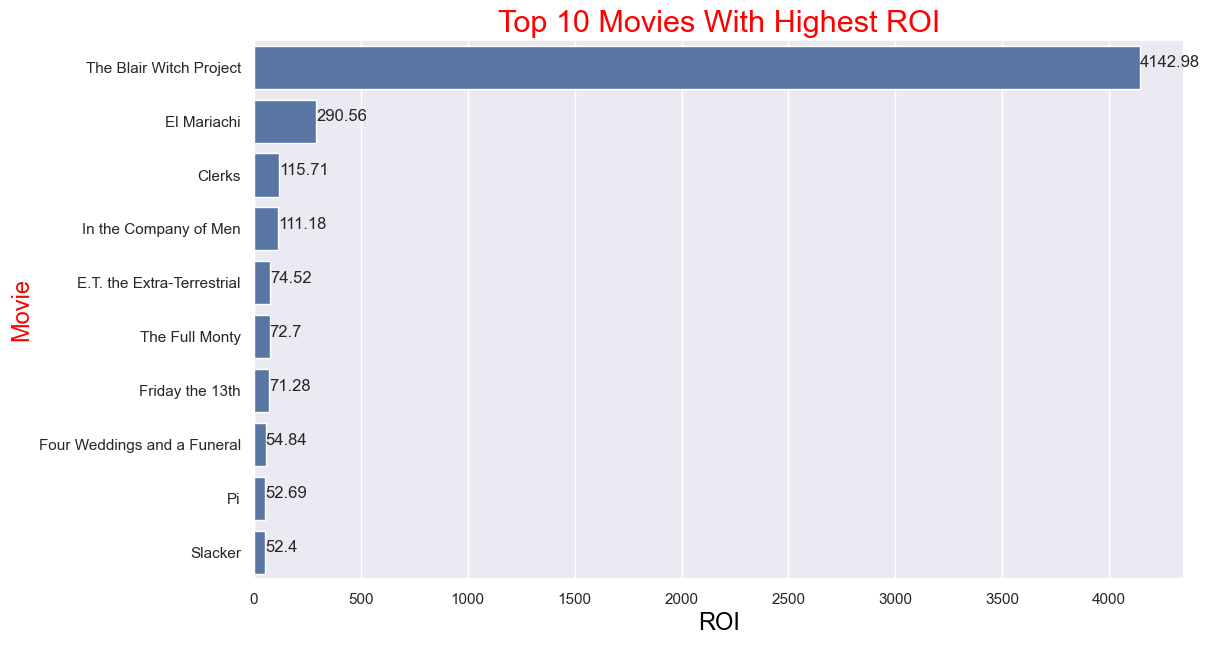

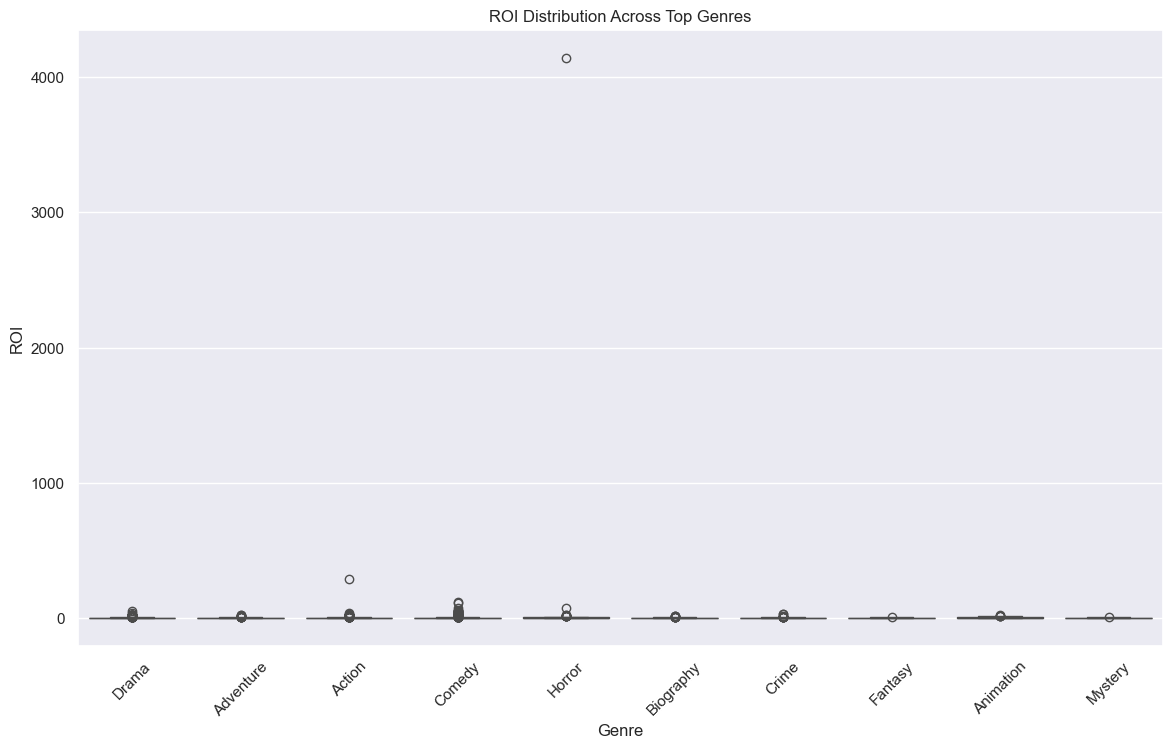

In [2]:
#########################################################################
#Exercise 1
# Tasks
# 1. Create a new feature called ROI:
# ROI = (gross - budget) / budget
# first remove zero value from budget data
movies = movies[movies["budget"] > 0]
movies["ROI"]=(movies["gross"]-movies["budget"])/movies["budget"]
# print(movies[["name", "budget", "gross", "ROI"]].head())

######################################################################
# 2. Remove movies with missing values in budget , gross , or score .
# check isnull the value of budget , gross , or score
print(movies[["budget", "gross", "score"]].isnull().sum())
movies = movies.dropna(subset=['budget', 'gross', 'score'])
# Verify
print(movies[["budget", "gross", "score"]].isnull().sum())

# #########################################################################
# 3. Create a scatter plot that simultaneously shows:
# Budget
# Gross Revenue
# Movie Score
# Number of Votes
plt.figure(figsize=(12,8))
sns.scatterplot(data=movies,x="budget",y="gross",size="votes",hue="score",alpha=1 , color="red")
movies = movies[movies["budget"] > 0]
plt.xscale("log")
plt.yscale("log")

# #########################################################################
# 4. Apply appropriate transformations if necessary to improve readability.
plt.title("Movie Budget vs Gross Revenue")
plt.xlabel("Budget(Log Scale)")
plt.ylabel("Gross Revenue (Log Scale)")
plt.legend()
plt.show()

# #########################################################################
# 5. Identify and annotate the 10 movies with the highest ROI.
top_roi = movies.sort_values("ROI",ascending=False).head(10) 
top_roi
plt.figure(figsize=(12,7))
sns.barplot(data=top_roi,x="ROI",y="name")
plt.title("Top 10 Movies With Highest ROI", color="red" , size=22)
plt.xlabel("ROI",color="black" , size=17)
plt.ylabel("Movie",color="red" , size=17)
# Add annotations
for i,value in enumerate(top_roi["ROI"]):
    plt.text(value,i,round(value,2))
plt.show()

# #########################################################################
# 6. Create a second visualization that compares ROI distributions across the top 10 genres
top_genres = (movies["genre"].value_counts().head(10).index)
genre_roi = movies[movies["genre"].isin(top_genres)]
plt.figure(figsize=(14,8))
sns.boxplot(data=genre_roi,x="genre",y="ROI")
plt.xticks(rotation=45)
plt.title("ROI Distribution Across Top Genres")
plt.xlabel("Genre")
plt.ylabel("ROI")
plt.show()

#########################################################################
# 7. Based on your visualizations, answer the following questions:
    #####################################################
    # Do larger budgets generally result in higher revenue?
        # Yes. The plot shows a positive relationship between budget and gross revenue.
        # Movies with higher budgets generally tend to earn higher revenue, although some
        # low-budget movies also perform well.
    #####################################################
    # Which genre appears to generate the highest returns relative to investment?
        # Based on the ROI analysis, low-budget genres such as Horror and Comedy usually
        # generatehigher ROI because they can make large profits with smaller investments.
    #####################################################
    # Are highly rated movies always financially successful?
        # No. The visualization shows that high scores do not always mean high revenue.
        # Some highly rated movies have fewer earnings, while some lower-rated movies 
        # achieve very high revenue due to popularity, marketing, and audience size.

Directors with at least 5 movies:
director
Woody Allen        22
Clint Eastwood     16
Directors          16
Barry Levinson     16
Joel Schumacher    15
                   ..
Luis Mandoki        5
Milos Forman        5
Emir Kusturica      5
Stuart Gordon       5
Bobby Farrelly      5
Name: count, Length: 216, dtype: int64
Company with at least 20 movies:
company
Universal Pictures            191
Paramount Pictures            191
Columbia Pictures             174
Warner Bros.                  165
Twentieth Century Fox         123
Touchstone Pictures            88
TriStar Pictures               80
New Line Cinema                80
Metro-Goldwyn-Mayer (MGM)      76
Orion Pictures                 57
Walt Disney Pictures           47
Castle Rock Entertainment      46
Hollywood Pictures             46
Miramax                        41
United Artists                 33
Morgan Creek Entertainment     30
Carolco Pictures               25
New World Pictures             20
Name: count, dtype: int

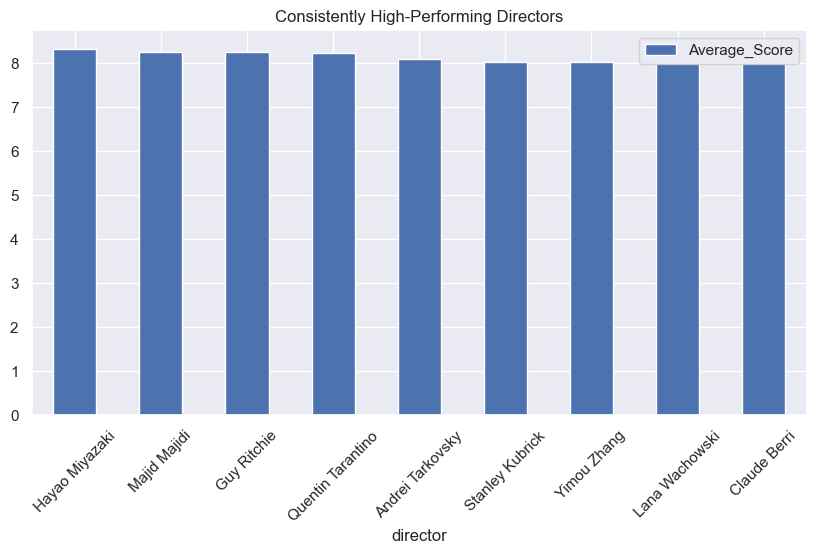

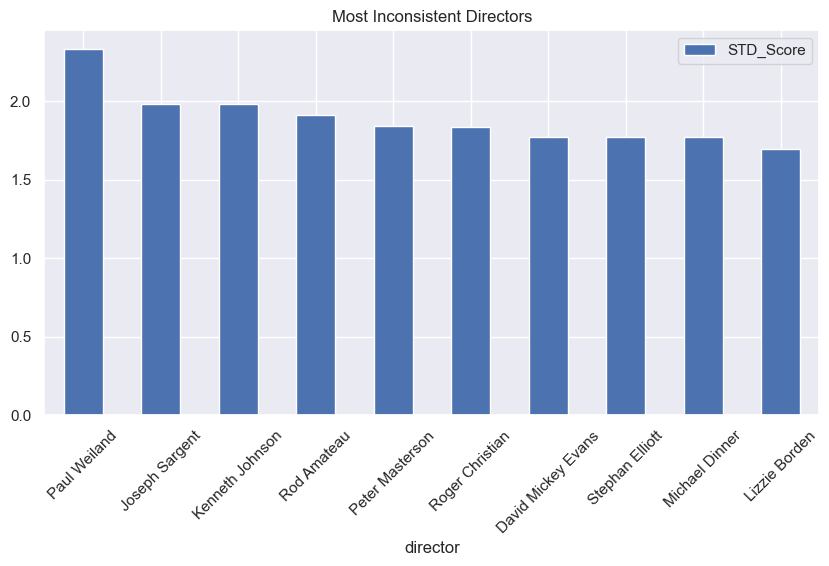

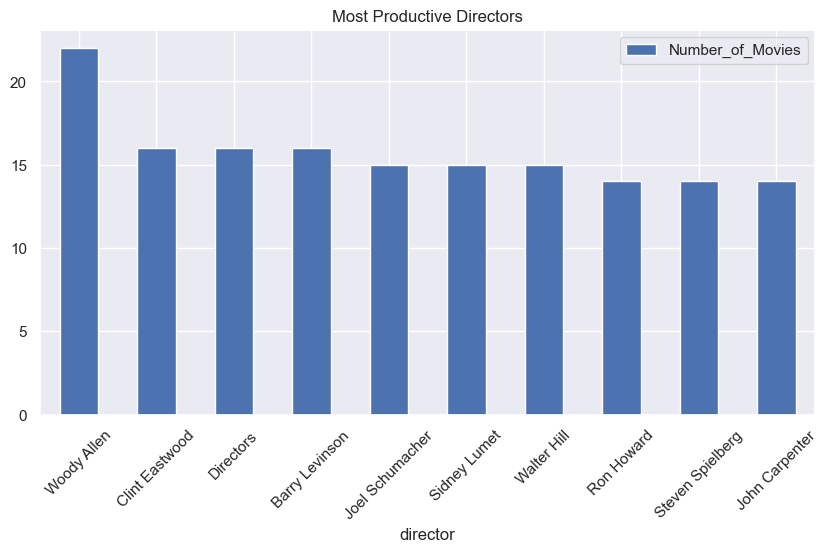

company
.406 Production                      10580.0
1492 Pictures                    108628125.0
1818 Productions                  12232628.0
21st Century Film Corporation      5835247.0
21st Century Films                 1702394.0
Name: gross, dtype: float64
company
.406 Production                 -0.957680
1492 Pictures                    0.519056
1818 Productions                 1.446526
21st Century Film Corporation    0.389345
21st Century Films              -0.659521
Name: ROI, dtype: float64
company
.406 Production                  6.80
1492 Pictures                    6.25
1818 Productions                 6.30
21st Century Film Corporation    6.90
21st Century Films               4.90
Name: score, dtype: float64
company
.406 Production                  1
1492 Pictures                    2
1818 Productions                 1
21st Century Film Corporation    1
21st Century Films               1
Name: name, dtype: int64
                               Average_Gross_Revenue  Average

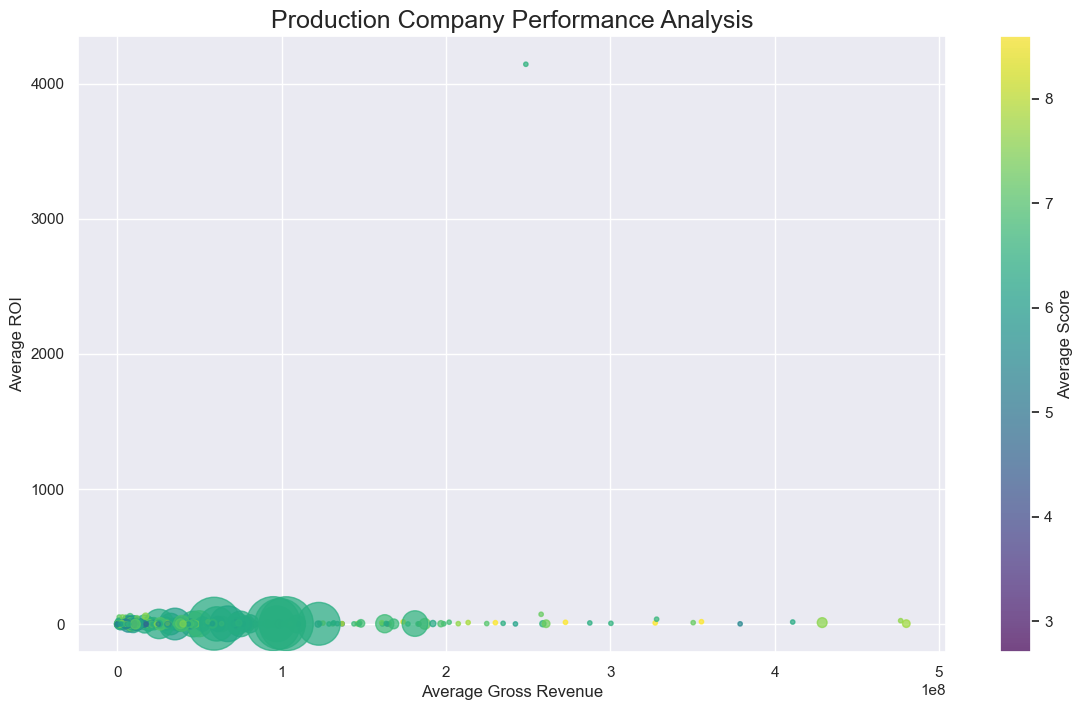

,Average_Gross_Revenue,Average_ROI,Average_Score,Number_of_Movies_Produced
company,,,,
Aries Cinematográfica Argentina,1.191925e+07,25.081510,4.600000,1
VAE Productions,1.060499e+07,23.952908,6.000000,1
Astral Bellevue Pathé,7.252447e+07,23.854801,5.600000,2
Hal Roach Studios,1.456899e+07,17.211236,5.600000,1
Hickmar Productions,4.319001e+06,16.276004,5.200000,1
Kasdan Pictures,4.110067e+08,15.440270,6.300000,1
Atlantic Entertainment Group,7.283213e+06,9.903027,5.314286,7
Cannon Entertainment,8.537628e+06,9.396752,6.000000,2
Cort/Madden Productions,1.317068e+08,9.131293,6.200000,1


In [5]:
# Exercise 2
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
movies=pd.read_csv("movies_updated.csv")
# movies.head(10)

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Tasks
# 1. Consider only:
# Directors with at least 5 movies.
director_counts = movies["director"].value_counts()
# Keep only directors with at least 5 movies
directors_5_plus = director_counts[director_counts >= 5]
print("Directors with at least 5 movies:")
print(directors_5_plus)

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
print("================================================================")
# Companies with at least 20 movies.
company_counts=movies["company"].value_counts()
# Keep only companies with at least 20 movies
comp_20_plus=company_counts[company_counts >= 20]
print("Company with at least 20 movies:")
print(comp_20_plus)

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# 2. For each director, calculate:
print("================================================================")
director_stats = movies.groupby("director")["score"] 
# Number of Movies
num_of_movies=director_stats.count()
# Average Score
average_score=director_stats.mean()
# Median Score
median_score=director_stats.median()
# Standard Deviation of Score
std_score=director_stats.std()

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# 3. Create a visualization that helps distinguish:
# Combine all results into one dataframe
director_stats = pd.DataFrame({
    "Number_of_Movies": num_of_movies,
    "Average_Score": average_score,
    "Median_Score": median_score,
    "STD_Score": std_score
})
print(director_stats.head())

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Consistently high-performing directors
consistent_high = director_stats[
    (director_stats["Average_Score"] >= 8) &
    (director_stats["STD_Score"] < 1)
]
consistent_high.sort_values(by="Average_Score",ascending=False).head(10).plot(
    kind="bar",y="Average_Score",figsize=(10,5),
    title="Consistently High-Performing Directors")
plt.xticks(rotation=45)
plt.show()

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Inconsistent directors
inconsistent = director_stats.sort_values(by="STD_Score",ascending=False).head(10)
inconsistent.plot(
    kind="bar",y="STD_Score",figsize=(10,5),
    title="Most Inconsistent Directors"
)
plt.xticks(rotation=45)
plt.show()
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Highly productive directors
productive = director_stats.sort_values(by="Number_of_Movies",ascending=False).head(10)
productive.plot(
    kind="bar",y="Number_of_Movies",figsize=(10,5),
    title="Most Productive Directors")
plt.xticks(rotation=45)
plt.show()

# Consistently High-Performing Directors → ከፍተኛ Average Score እና ዝቅተኛ STD Score ያላቸው።
# Inconsistent Directors → ከፍተኛ STD Score ያላቸው፣ የፊልም ውጤታቸው በጣም የሚለያይ።
# Highly Productive Directors → ብዙ ፊልሞችን የሰሩ፣ Number_of_Movies ከፍተኛ የሆነላቸው።
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
movies = movies[movies["budget"] > 0]
movies["ROI"] = (movies["gross"] - movies["budget"]) / movies["budget"]
# 4. For production companies, calculate:
print("================================================================")
company_stats = movies.groupby("company")

# Average Gross Revenue
avg_gross = company_stats["gross"].mean()
print(avg_gross.head())
print("================================================================")

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Average ROI
avg_roi = company_stats["ROI"].mean()
print(avg_roi.head())
print("================================================================")

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Average Score
avg_score = company_stats["score"].mean()
print(avg_score.head())
print("================================================================")

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Number of Movies Produced
num_movies = company_stats["name"].count()
print(num_movies.head())
print("================================================================")

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# 5. Create a visualization that displays all four metrics simultaneously.
# Visualization showing all four metrics
# Combine all company metrics into one dataframe
company_stats = pd.DataFrame({
    "Average_Gross_Revenue": avg_gross,
    "Average_ROI": avg_roi,
    "Average_Score": avg_score,
    "Number_of_Movies_Produced": num_movies
})
print(company_stats.head())

print("%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%")
plt.figure(figsize=(14,8))
scatter = plt.scatter(
    company_stats["Average_Gross_Revenue"],
    company_stats["Average_ROI"],
    s=company_stats["Number_of_Movies_Produced"] * 10,
    c=company_stats["Average_Score"],
    cmap="viridis",
    alpha=0.7)
plt.colorbar(scatter, label="Average Score")
plt.title("Production Company Performance Analysis", fontsize=18)
plt.xlabel("Average Gross Revenue")
plt.ylabel("Average ROI")
plt.show()
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# 6. Using your visualizations:
# Identify three directors who are consistently successful.
consistent_high.sort_values(by="Average_Score",ascending=False).head(3)

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Identify companies that prioritize quality over profitability.
quality_companies = company_stats[
    (company_stats["Average_Score"] >= company_stats["Average_Score"].median()) &
    (company_stats["Average_ROI"] < company_stats["Average_ROI"].median())
]
quality_companies.sort_values(by="Average_Score",ascending=False).head(10)

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Identify companies that prioritize profitability over quality.
profit_companies = company_stats[
    (company_stats["Average_ROI"] >= company_stats["Average_ROI"].median()) &
    (company_stats["Average_Score"] < company_stats["Average_Score"].median())
]
profit_companies.sort_values(by="Average_ROI",ascending=False).head(10)

                  Number_of_Movies  Average_Score  Total_Gross_Revenue
decade genre                                                          
1980s  Action                  229       6.165502         1.083790e+10
       Adventure                74       6.174324         2.502041e+09
       Animation                20       7.130000         9.526155e+08
       Biography                36       7.038889         1.160968e+09
       Comedy                  287       6.245645         8.896916e+09




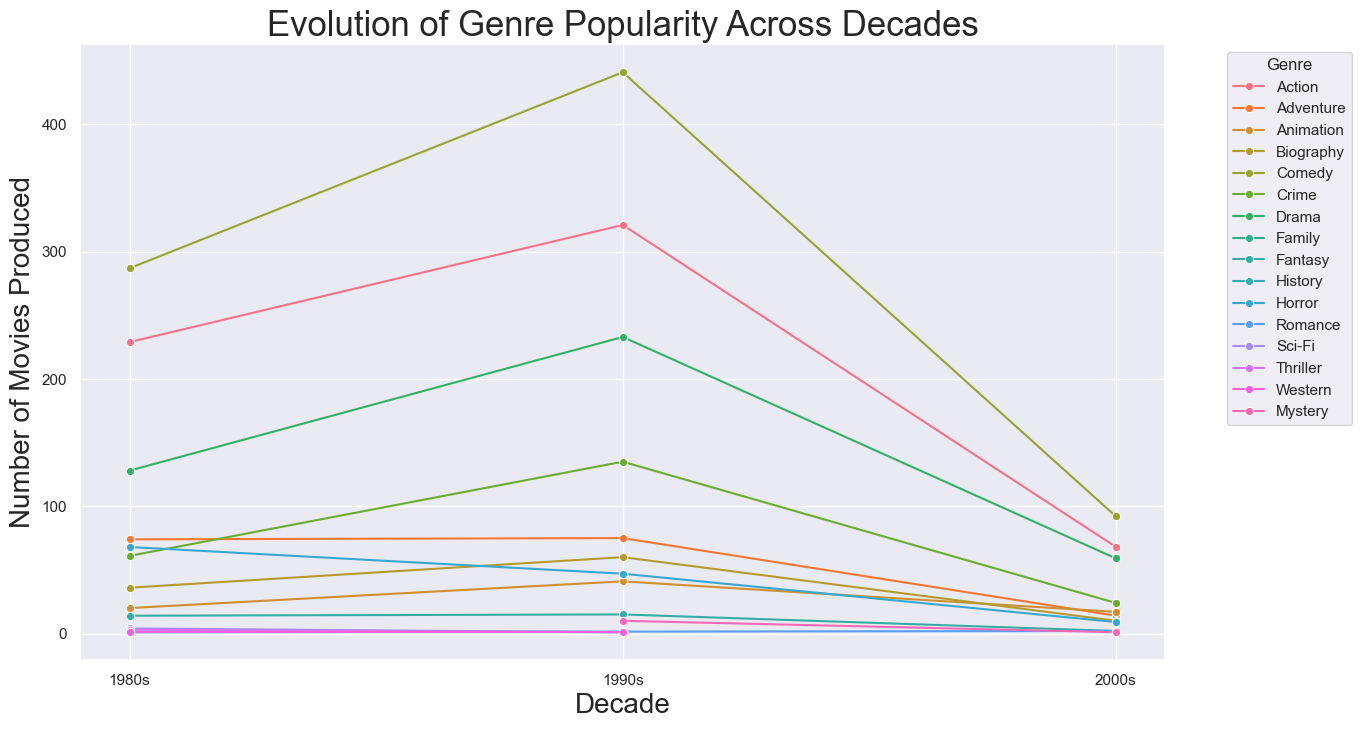

Countries with at least 30 movies:
country
United States     2145
United Kingdom     206
Canada              46
France              43
Name: count, dtype: int64
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                Average_Score  Average_Budget  Average_Gross  Average_ROI
country                                                                  
Canada               5.910870    1.324349e+07   1.641894e+07     3.821059
France               6.653488    2.969767e+07   3.671473e+07     0.396613
United Kingdom       6.513107    1.986090e+07   3.672382e+07     1.412941
United States        6.305128    2.445151e+07   6.177427e+07     4.032670


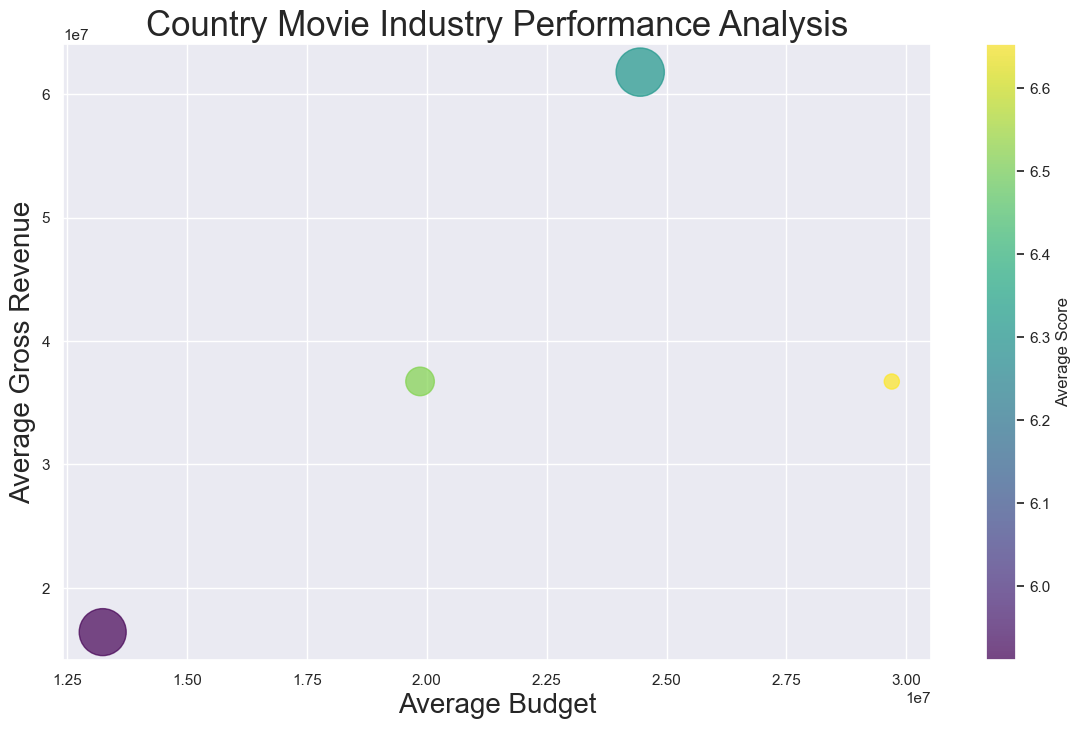

Hidden_Gem
False    2603
True        5
Name: count, dtype: int64
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
       genre                country  Number_of_Hidden_Gems
0  Biography                  Libya                      1
1  Biography          United States                      1
2     Comedy           Soviet Union                      1
3      Drama  Republic of Macedonia                      1
4    History                 Canada                      1


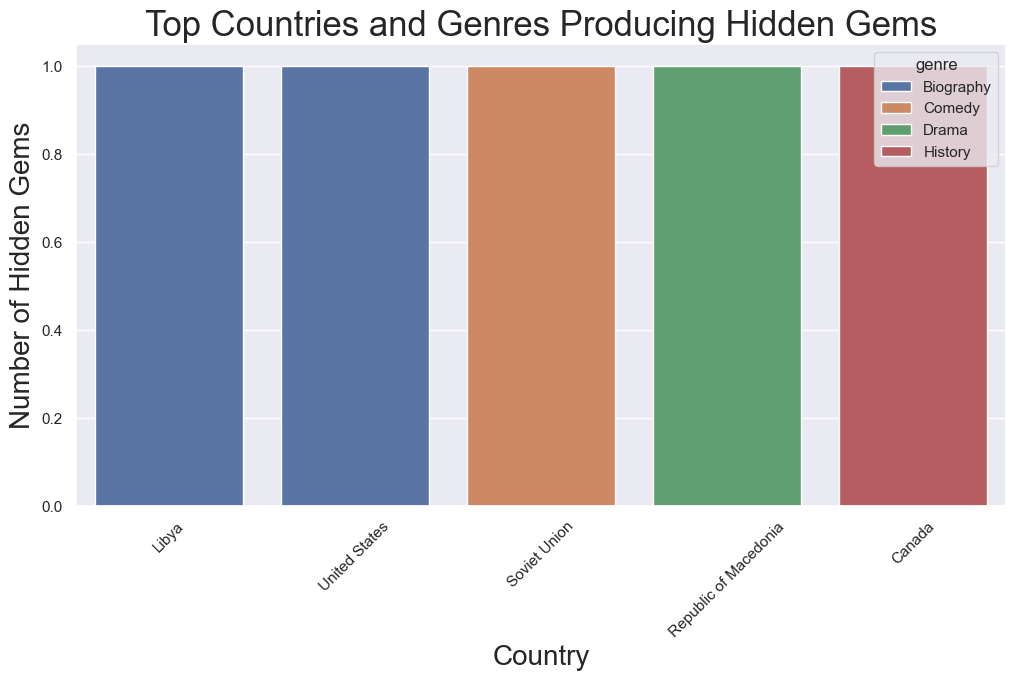

,genre,country,Number_of_Hidden_Gems
0,Biography,Libya,1
1,Biography,United States,1
2,Comedy,Soviet Union,1
3,Drama,Republic of Macedonia,1
4,History,Canada,1


In [4]:
# Exercise 3
# Tasks
# 1. Create decade groups from the movie release year.
# Check for missing values in year
movies = movies.dropna(subset=["year"])
# Convert year to integer
movies["year"] = movies["year"].astype(int)
# Create decade groups
movies["decade"] = (movies["year"] // 10) * 10
# Add label for better readability
movies["decade"] = movies["decade"].astype(str) + "s"
# Display result
movies[["year", "decade"]].head()

#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
# 2. For each decade and genre, calculate:
decade_genre = movies.groupby(["decade", "genre"])
# Number of Movies
num_movies = decade_genre["name"].count()
# Average Score
avg_score = decade_genre["score"].mean()
# Total Gross Revenue
total_gross = decade_genre["gross"].sum()


# Combine into one DataFrame
decade_genre_stats = pd.DataFrame({
    "Number_of_Movies": num_movies,
    "Average_Score": avg_score,
    "Total_Gross_Revenue": total_gross})
print(decade_genre_stats.head())

print("\n")
#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
# 3. Visualization: Genre popularity evolution across decades
# Reset index for visualization
genre_trend = decade_genre_stats.reset_index()
# Create line plot
plt.figure(figsize=(14,8))
sns.lineplot(data=genre_trend,x="decade",y="Number_of_Movies",hue="genre",marker="o")
plt.title("Evolution of Genre Popularity Across Decades",fontsize=25)
plt.xlabel("Decade",fontsize=20)
plt.ylabel("Number of Movies Produced",fontsize=20)
plt.legend(title="Genre",bbox_to_anchor=(1.05,1),loc="upper left")
plt.grid(True)
plt.show()

#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
# 4. Consider only countries with at least 30 movies.
# Count movies per country
country_counts = movies["country"].value_counts()
# Keep countries with at least 30 movies
countries_30_plus = country_counts[country_counts >= 30]
print("Countries with at least 30 movies:")
print(countries_30_plus)
print("%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%")
#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
# 5. For each country, calculate:
# Keep only countries with >=30 movies
movies_country = movies[
    movies["country"].isin(countries_30_plus.index)
]
# Group by country
country_stats = movies_country.groupby("country")
# Average Score
avg_score = country_stats["score"].mean()
# Average Budget
avg_budget = country_stats["budget"].mean()
# Average Gross Revenue
avg_gross = country_stats["gross"].mean()
# Average ROI
avg_roi = country_stats["ROI"].mean()
# Combine results
country_analysis = pd.DataFrame({
    "Average_Score": avg_score,
    "Average_Budget": avg_budget,
    "Average_Gross": avg_gross,
    "Average_ROI": avg_roi
})
print(country_analysis.head())

#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
# 6. Create a single visualization that compares countries using all four metrics.
# Country comparison visualization
plt.figure(figsize=(14,8))
scatter = plt.scatter(
    country_analysis["Average_Budget"],country_analysis["Average_Gross"],
    s=country_analysis["Average_ROI"] * 300,c=country_analysis["Average_Score"],
    cmap="viridis",alpha=0.7)
plt.colorbar(scatter,label="Average Score")
plt.title("Country Movie Industry Performance Analysis",fontsize=25)
plt.xlabel("Average Budget",fontsize=20)
plt.ylabel("Average Gross Revenue",fontsize=20)
plt.show()
#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
# 7. Define a Hidden Gem as:
# score >= 8
# votes < median(votes)
# Hidden Gem definition
median_votes = movies["votes"].median()
movies["Hidden_Gem"] = ((movies["score"] >= 8) & (movies["votes"] < median_votes))
print(movies["Hidden_Gem"].value_counts())
print("%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%")

#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
# 8. Calculate the number of hidden gems produced by each genre and country.
hidden_gems = movies[ movies["Hidden_Gem"] == True]
hidden_gem_stats = hidden_gems.groupby(["genre","country"]).size()
hidden_gem_stats = hidden_gem_stats.reset_index(name="Number_of_Hidden_Gems")
print(hidden_gem_stats.head())

#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
# 9. Create a visualization that highlights where hidden gems are most commonly found.
top_hidden = hidden_gem_stats.sort_values(by="Number_of_Hidden_Gems",ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(data=top_hidden,x="country",y="Number_of_Hidden_Gems",hue="genre")
plt.title("Top Countries and Genres Producing Hidden Gems" , fontsize=25)
plt.xlabel("Country",fontsize=20)
plt.ylabel("Number of Hidden Gems",fontsize=20)
plt.xticks(rotation=45)
plt.show()

#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
# 10. Based on your analysis, answer the following questions:
# Which genres gained popularity over time?
movies.groupby(["decade","genre"]).size()

# Which countries produce the highest-quality movies relative to budget?
country_analysis.sort_values("Average_ROI",ascending=False).head()

# Which genre and country combinations appear to be the most underrated by audiences?
hidden_gem_stats.sort_values("Number_of_Hidden_Gems",ascending=False).head(10)

# Countries with fewer than 30 movies were excluded to avoid unreliable averages.
# ROI was calculated only when budget > 0.
# Hidden gems are defined only using score and votes.
# Movie popularity is measured by number of productions.